In [64]:
import numpy as np
import matplotlib.pyplot as plt

In [65]:
# Gravitational constant, Earth's mass, and orbital radius
G = 6.674e-11
M = 5.9722e24
R_earth = 6.371e6
r_orbit = 6.771e6    

In [66]:
# Starting positions and velocity
v = np.sqrt((G*M) / r_orbit)
r0 = np.array([r_orbit, 0.0])
v0 = np.array([0.0, v])
print(f"Starting point is {r0}")
print(f"Initial Velocity is {v0}")

Starting point is [6771000.       0.]
Initial Velocity is [   0.         7672.44644817]


In [67]:
def acceleration(r):
    r_mag = np.linalg.norm(r)
    return -(G * M / r_mag**3) * r

In [68]:
test_accel = acceleration(r0)
print(f"Acceleration vector: {test_accel}")
print(f"Magnitude: {np.linalg.norm(test_accel):.4f} m/s²")
print(f"Direction check — should point in -x: {test_accel[0] < 0 and test_accel[1] == 0.0}")

Acceleration vector: [-8.69390555 -0.        ]
Magnitude: 8.6939 m/s²
Direction check — should point in -x: True


In [69]:
# Period of Orbit
num_orbits = 5
T = 5560.0               # one orbital period (approximation)
print(f"Period of an orbit is {T:.1f} s ({T/60:.2f} min)")

# Time-Step
dt = 10.0
steps = int((num_orbits * T) / dt)
print(f"Steps: {steps}")
positions = np.zeros((steps, 2))

Period of an orbit is 5560.0 s (92.67 min)
Steps: 2780


In [70]:
# Euler
r = r0.copy()
v = v0.copy()

for i in range(steps):
    positions[i] = r       # Set current position
    a = acceleration(r)
    r = r + v * dt         # Update position
    v = v + a * dt         # Update velocity

print(positions)

[[ 6771000.                0.        ]
 [ 6771000.            76724.46448172]
 [ 6770130.60944469   153448.92896345]
 ...
 [-7463855.17862072 -6776343.84466324]
 [-7423129.97117684 -6823622.64906756]
 [-7382114.38562347 -6870637.82269827]]


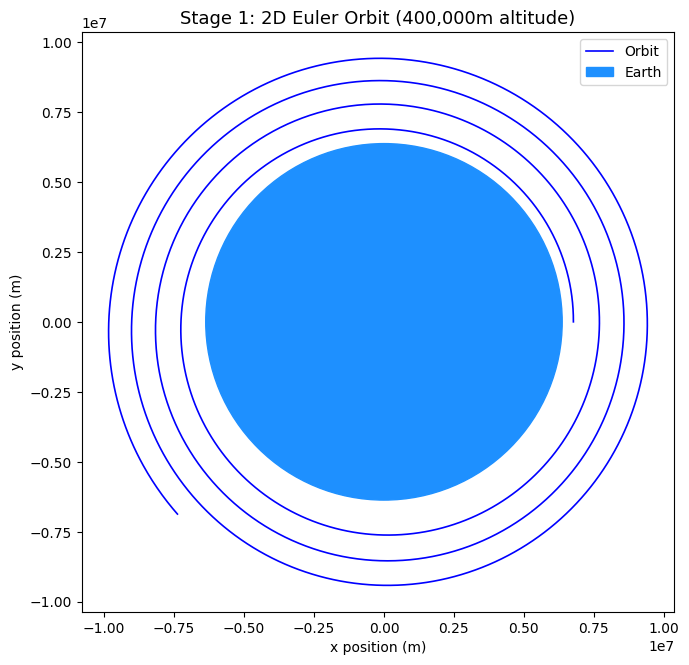

In [71]:
# plot to vizualize Euler
#print(positions[:,0])
x_coords = positions[:, 0]
y_coords = positions[:, 1]

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x_coords, y_coords, color="blue", lw=1.2, label="Orbit")

# Earth — Radius 6,371,000m
earth = plt.Circle((0,0), R_earth, color="dodgerblue", label="Earth")
ax.add_patch(earth)

ax.set_aspect("equal")
ax.set_title("Stage 1: 2D Euler Orbit (400,000m altitude)", fontsize=13)
ax.set_xlabel("x position (m)", fontsize=10)
ax.set_ylabel("y position (m)", fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig("/Users/yasha/Desktop/orbital-simulator/img/stage1_orbit_v2.png", dpi=150, bbox_inches="tight")
plt.show()

Text(0.5, 1.0, 'Orbital Drift (Radius vs Time)')

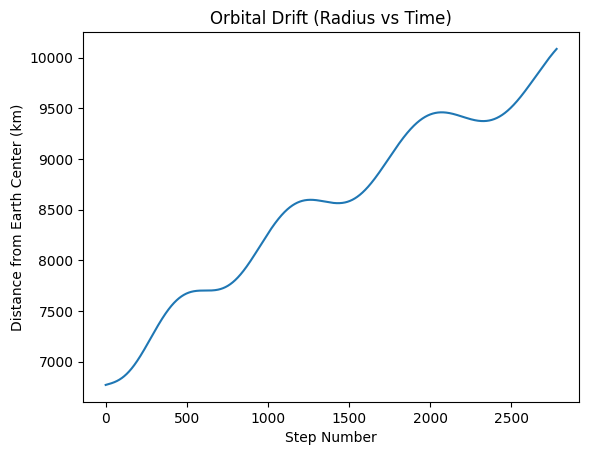

In [72]:
# Vizualizing Obital Drift
distances = np.linalg.norm(positions, axis=1)
plt.plot(distances / 1000) # Plot in km
plt.ylabel("Distance from Earth Center (km)")
plt.xlabel("Step Number")
plt.title("Orbital Drift (Radius vs Time)")

In [73]:
# Kepler Third Law: T = 2*pi * sqrt(r_orbit^3 / GM)
T_kepler = 2 * np.pi * np.sqrt(r_orbit**3 / (G * M))

T_simulated =  (steps * dt) / num_orbits 
error_pct = abs(T_simulated - T_kepler) / T_kepler * 100
print(f"Kepler period: {T_kepler:.1f} s ({T_kepler/60:.2f} min)")
print(f"Simulated Period: {T_simulated:.1f} s")
print((f"period error: {error_pct:.2f}%"))
print(f"Direction check: T_simulated {'>' if T_simulated > T_kepler else '<'} T_kepler — "
      f"{'consistent with Euler energy gain' if T_simulated > T_kepler else 'unexpected — check integrator'}")

Kepler period: 5545.0 s (92.42 min)
Simulated Period: 5560.0 s
period error: 0.27%
Direction check: T_simulated > T_kepler — consistent with Euler energy gain
